# 🎯 Return, Risk, Slope Detector

## Import Library & Global Variabels

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt

# Load Modul
from src.data_loader import load_stock_data, dataset_splitting, target_distribution
from src.visualizer import plot_interactive_candlestick, cek_missing_value
from src.features import create_features
from src.label import create_labels
from src.model_config import FEATURES, REGRESSOR_BASELINE_CONFIG, REGRESSOR_CONFIGS
from src.modelling import ModellingPipeline, ModelEvaluator

# Import Scikit-Learn Modul
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.dummy import DummyRegressor

# ==================== KONFIGURASI ====================
TICKER = 'BBRI.JK'
IN_SAMPLE_START = "2014-11-01"
IN_SAMPLE_END = '2023-12-31'    # Data latih: 2015 - 2023
OOS_START = '2024-01-01'        # Data uji: 2024 - 2025
OOS_END = '2025-12-31'
TODAY = datetime.now().strftime('%Y-%m-%d')
WINDOW = 5
LAST_20_DAYS = (datetime.now() - timedelta(days=20)).strftime('%Y-%m-%d')
TARGET_NAME = ['return', 'risk', 'trend_slope']

# Model yang ingin diadu
MODELS_NAME = [
    'ridge_regression', 'elastic_net', 'random_forest', 'extra_trees', 
    'xgboost', 'lightgbm', 'catboost', 'svr', 'knn', 'poisson_regression',
    # 'tabnet', 'lstm', 'gru', 'tcn', 'transformer', 
]

print(f"Ticker's Name: {TICKER}")
print(f"N Features   : {len(FEATURES)} fitur")
print(f"Features     : {FEATURES}")
print(f"N Targets    : {len(TARGET_NAME)} label")
print(f"Targets      : {TARGET_NAME}")
print(f"Models       : {MODELS_NAME}")

Ticker's Name: BBRI.JK
N Features   : 21 fitur
Features     : ['ATR', 'RSI', 'Volume_Ratio', 'Log_Return', 'distance_to_support', 'distance_to_resistance', 'MACD_Hist', 'Dist_to_MA20', 'Hist_Volatility_5d', 'RSI_3', 'BB_Pct', 'Capitulation_Vol', 'Lower_Shadow_Pct', 'Upper_Shadow_Pct', 'Body_Pct', 'Williams_R', 'Dist_to_MA50', 'EMA50_Slope', 'ATR_Pct_Change', 'BB_Width', 'Volume_Spike']
N Targets    : 3 label
Targets      : ['return', 'risk', 'trend_slope']
Models       : ['ridge_regression', 'elastic_net', 'random_forest', 'extra_trees', 'xgboost', 'lightgbm', 'catboost', 'svr', 'knn', 'poisson_regression']


## Import Data

In [2]:
# ==================== LOAD & PREPARE DATA ====================
df_raw = load_stock_data(ticker=TICKER, start_date=IN_SAMPLE_START, end_date=TODAY)
df = df_raw.copy()
df = create_features(df)
df = create_labels(df, window=WINDOW)
df = df.dropna()

X = df[FEATURES]
y = df[TARGET_NAME]

# Split In-Sample dan Out-of-Sample
X_in_sample, y_in_sample, X_out_sample, y_out_sample, X_forward, y_forward = dataset_splitting(X, y, IN_SAMPLE_START, IN_SAMPLE_END, OOS_START, OOS_END)

df_in_sample = pd.concat([X_in_sample, y_in_sample], axis=1).copy()
df_out_sample = pd.concat([X_out_sample, y_out_sample], axis=1).copy()
df_forward = pd.concat([X_forward, y_forward], axis=1).copy()

print("\n====== REKAPITULASI PEMISAHAN DATA ======")
print(f"📊 Total Data         : {X.shape[0]} baris")
print(f"📂 Data In-Sample     : {X_in_sample.shape[0]} baris ({df_in_sample.index[0].date()} s.d {df_in_sample.index[-1].date()})")
print(f"🔒 Data Out-of-Sample : {X_out_sample.shape[0]} baris ({df_out_sample.index[0].date()} s.d {df_out_sample.index[-1].date()})")
print(f"⏩ Data Forward Test  : {X_forward.shape[0]} baris ({df_forward.index[0].date()} s.d {df_forward.index[-1].date()})")

print("\n"+ "=" * 50)
print(f"FULL DATASET :  {len(X)} Baris")
print("=" * 50)
target_distribution(df, TARGET_NAME)

print("\n"+ "=" * 50)
print(f"DF IN SAMPLE :  {len(X_in_sample)} Baris")
print("=" * 50)
target_distribution(df_in_sample, TARGET_NAME)

print("\n"+ "=" * 50)
print(f"DF OUT SAMPLE :  {len(X_out_sample)} Baris")
print("=" * 50)
target_distribution(df_out_sample, TARGET_NAME)

Mengunduh data terbaru untuk BBRI.JK dari Yahoo Finance...
Berhasil memuat 2915 baris data untuk BBRI.JK.
Info Data Cleaning: Menghapus 73 baris data (NaN atau Volume 0).
Berhasil memuat 2842 baris data bersih untuk BBRI.JK.


c:\Users\YOGA\Downloads\Gagah Personal\Repositories\stock-forecasting\notebook\..\src\features.py:218: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['ATR_Pct_Change'] = (atr_raw.pct_change(periods=5)).shift(1)



====== REKAPITULASI PEMISAHAN DATA ======
📊 Total Data         : 2788 baris
📂 Data In-Sample     : 2161 baris (2015-01-16 s.d 2023-12-29)
🔒 Data Out-of-Sample : 473 baris (2024-01-02 s.d 2025-12-30)
⏩ Data Forward Test  : 154 baris (2026-01-02 s.d 2026-08-31)

FULL DATASET :  2788 Baris


,Valid,NaN,% Positif (>0),% Nol (==0),% Negatif (<0),Min,Median,Mean,Max
Target,,,,,,,,,
return,2788,0,2628 hari (94.3%)%,160 hari (5.7%),0 hari (0.0%),0.00%,2.15%,3.10%,46.80%
risk,2788,0,0 hari (0.0%)%,165 hari (5.9%),2623 hari (94.1%),-27.20%,-2.15%,-2.96%,0.00%
trend_slope,2788,0,1479 hari (53.0%)%,17 hari (0.6%),1292 hari (46.3%),-0.0537,0.0006,0.0006,0.0643



DF IN SAMPLE :  2161 Baris


,Valid,NaN,% Positif (>0),% Nol (==0),% Negatif (<0),Min,Median,Mean,Max
Target,,,,,,,,,
return,2161,0,2027 hari (93.8%)%,134 hari (6.2%),0 hari (0.0%),0.00%,2.07%,3.08%,46.80%
risk,2161,0,0 hari (0.0%)%,142 hari (6.6%),2019 hari (93.4%),-27.20%,-2.05%,-2.85%,0.00%
trend_slope,2161,0,1171 hari (54.2%)%,10 hari (0.5%),980 hari (45.3%),-0.0537,0.0008,0.0008,0.0643



DF OUT SAMPLE :  473 Baris


,Valid,NaN,% Positif (>0),% Nol (==0),% Negatif (<0),Min,Median,Mean,Max
Target,,,,,,,,,
return,473,0,453 hari (95.8%)%,20 hari (4.2%),0 hari (0.0%),0.00%,2.38%,3.07%,14.06%
risk,473,0,0 hari (0.0%)%,18 hari (3.8%),455 hari (96.2%),-13.85%,-2.80%,-3.29%,0.00%
trend_slope,473,0,228 hari (48.2%)%,5 hari (1.1%),240 hari (50.7%),-0.0331,-0.0002,-0.0004,0.0386


## Deep Analysis

In [3]:
df_dummy_pred = df.copy()
rr_ratio = df_dummy_pred['return'] / df_dummy_pred['risk'].abs().clip(lower=0.01)
df_dummy_pred['actual_rr_ratio'] = rr_ratio
df_dummy_pred['raw_buy_signal'] = (df_dummy_pred['trend_slope'] > 0) & (rr_ratio >= 9)

signal_counts = df_dummy_pred['raw_buy_signal'].value_counts()
total_days = len(df_dummy_pred)
n_buy = signal_counts.get(True, 0)
n_no_buy = signal_counts.get(False, 0)
n_nan = df_dummy_pred['raw_buy_signal'].isna().sum()
print("=== Distribusi Sinyal 'raw_buy_signal' ===")
print(f"  Total               : {total_days} hari (100.0%)")
print(f"  False (Bukan Sinyal): {n_no_buy} hari ({n_no_buy/total_days*100:.1f}%)")
print(f"  True  (Sinyal Beli) : {n_buy} hari ({n_buy/total_days*100:.1f}%)")
print(f"  NaN                 : {n_nan} hari\n")

plot_interactive_candlestick(
    df=df_dummy_pred, 
    ticker_name=TICKER, 
    predictions_df=df_dummy_pred,
    show_raw_buy_signals=True
)


=== Distribusi Sinyal 'raw_buy_signal' ===
  Total               : 2788 hari (100.0%)
  False (Bukan Sinyal): 2707 hari (97.1%)
  True  (Sinyal Beli) : 81 hari (2.9%)
  NaN                 : 0 hari



--- PEMERIKSAAN DATA ---
Total missing values di X(2161, 21): 0
Total missing values di y(2161, 3): 0
------------------------------
Data Bersih, data X dan y 100% bersih dari missing values.


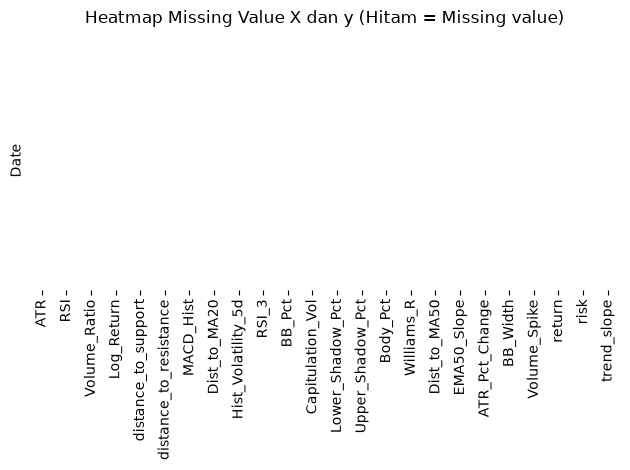

In [4]:
cek_missing_value(X_in_sample, y_in_sample)

## Modelling

In [5]:
summary_reports = []
clean_ticker = TICKER.split('.')[0].lower()

for target in TARGET_NAME:
    print(f"\n==================================================")
    print(f"MENCARI MODEL TERBAIK VARIABEL TARGET: {target.upper()}")
    print(f"==================================================")

    # Buat list untuk menampung hasil metrik semua model untuk target ini
    target_metrics_results = []
    trained_pipelines = {}
    
    # 1. Latih & Tuning Baseline
    print("[1] Menyetel Baseline Model (DummyRegressor)...")
    pipeline_bl = ModellingPipeline(target_name=target, feature_cols=FEATURES)
    X_bl, y_bl = pipeline_bl.prepare_data(df_in_sample)
    pipeline_bl.tune_and_fit(X_bl, y_bl, REGRESSOR_BASELINE_CONFIG['model_object'], REGRESSOR_BASELINE_CONFIG['grid_params'])

    # Simpan metrik baseline
    bl_metrics = pipeline_bl.metrics.copy()
    bl_metrics['Model'] = REGRESSOR_BASELINE_CONFIG['name']
    target_metrics_results.append(bl_metrics)

    trained_pipelines[REGRESSOR_BASELINE_CONFIG['name']] = pipeline_bl

    # 2. Latih & Tuning Model Tandingan
    for model_name in MODELS_NAME:
        if model_name == 'poisson_regression' and target not in ['days_to_max', 'days_to_min']:
            print(f"[-] Melewati {model_name} untuk target '{target.upper()}' (Tidak kompatibel dengan nilai negatif).")
            continue
        
        model = REGRESSOR_CONFIGS[model_name]
        print(f"[{MODELS_NAME.index(model_name)+2}] Menyetel Model Pilihan ({model['model_object'].__class__.__name__} | {model_name})...")
        pipeline_choice = ModellingPipeline(target_name=target, feature_cols=FEATURES)
        X_c, y_c = pipeline_choice.prepare_data(df_in_sample)
        pipeline_choice.tune_and_fit(X_c, y_c, model['model_object'], model['grid_params'])

        # Simpan metrik model
        mod_metrics = pipeline_choice.metrics.copy()
        mod_metrics['Model'] = model_name
        target_metrics_results.append(mod_metrics)

        trained_pipelines[model_name] = pipeline_choice

    # 3. Evaluasi & Pemilihan Model Terbaik
    df_results = pd.DataFrame(target_metrics_results)
    
    evaluator = ModelEvaluator(target_name=target, baseline_name=REGRESSOR_BASELINE_CONFIG['name'])
    report_dict = evaluator.generate_evaluation_report(df_results)
    summary_reports.append(report_dict)

    best_model_name = report_dict['Model Terpilih']
    best_pipeline = trained_pipelines[best_model_name]
    best_pipeline.save(folder_path="../models", ticker=clean_ticker)
    print(f">> Model '{best_model_name}' berhasil disimpan untuk target '{target}'.")
    print(f"")

# Tampilkan Laporan Visual Side-by-Side
print("\n" + "="*20 + " LAPORAN EVALUASI & OVERFIT DETECTOR " + "="*20)
df_report = pd.DataFrame(summary_reports)
print(df_report.to_string(index=False))



MENCARI MODEL TERBAIK VARIABEL TARGET: RETURN
[1] Menyetel Baseline Model (DummyRegressor)...
   -> [HYPERPARAMETERS]: {}
   -> [TRAIN]: train MAE 0.0232 | Hit Rate 49.79%
   -> [EVAL]: val MAE 0.0234
[2] Menyetel Model Pilihan (Ridge | ridge_regression)...
   -> [HYPERPARAMETERS]: {'alpha': 100.0}
   -> [TRAIN]: train MAE 0.0212 | Hit Rate 57.01%
   -> [EVAL]: val MAE 0.0213
[3] Menyetel Model Pilihan (ElasticNet | elastic_net)...
   -> [HYPERPARAMETERS]: {'alpha': 0.1, 'l1_ratio': 0.2}
   -> [TRAIN]: train MAE 0.0232 | Hit Rate 49.79%
   -> [EVAL]: val MAE 0.0234
[4] Menyetel Model Pilihan (RandomForestRegressor | random_forest)...
   -> [HYPERPARAMETERS]: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
   -> [TRAIN]: train MAE 0.0205 | Hit Rate 55.21%
   -> [EVAL]: val MAE 0.0221
[5] Menyetel Model Pilihan (ExtraTreesRegressor | extra_trees)...
   -> [HYPERPARAMETERS]: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}
   -> [TRAIN]: train MAE 0.0211 | Hit R

c:\Users\YOGA\Downloads\Gagah Personal\Repositories\stock-forecasting\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   -> [HYPERPARAMETERS]: {'depth': 4, 'iterations': 200, 'learning_rate': 0.01}
   -> [TRAIN]: train MAE 0.0209 | Hit Rate 54.10%
   -> [EVAL]: val MAE 0.0219
[9] Menyetel Model Pilihan (SVR | svr)...
   -> [HYPERPARAMETERS]: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf'}
   -> [TRAIN]: train MAE 0.0158 | Hit Rate 70.99%
   -> [EVAL]: val MAE 0.0232
[10] Menyetel Model Pilihan (KNeighborsRegressor | knn)...
   -> [HYPERPARAMETERS]: {'n_neighbors': 21, 'weights': 'uniform'}
   -> [TRAIN]: train MAE 0.0206 | Hit Rate 59.09%
   -> [EVAL]: val MAE 0.0227
[-] Melewati poisson_regression untuk target 'RETURN' (Tidak kompatibel dengan nilai negatif).
[SAVED] Berhasil mengekspor model regressor ke: ../models/bbri/model_return_bbri.pkl
>> Model 'knn' berhasil disimpan untuk target 'return'.


MENCARI MODEL TERBAIK VARIABEL TARGET: RISK
[1] Menyetel Baseline Model (DummyRegressor)...
   -> [HYPERPARAMETERS]: {}
   -> [TRAIN]: train MAE 0.0208 | Hit Rate 75.89%
   -> [EVAL]: val MAE 0.0209
[2] Meny

c:\Users\YOGA\Downloads\Gagah Personal\Repositories\stock-forecasting\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   -> [HYPERPARAMETERS]: {'depth': 8, 'iterations': 100, 'learning_rate': 0.01}
   -> [TRAIN]: train MAE 0.0188 | Hit Rate 75.24%
   -> [EVAL]: val MAE 0.0204
[9] Menyetel Model Pilihan (SVR | svr)...
   -> [HYPERPARAMETERS]: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf'}
   -> [TRAIN]: train MAE 0.0141 | Hit Rate 73.60%
   -> [EVAL]: val MAE 0.0211
[10] Menyetel Model Pilihan (KNeighborsRegressor | knn)...
   -> [HYPERPARAMETERS]: {'n_neighbors': 21, 'weights': 'uniform'}
   -> [TRAIN]: train MAE 0.0184 | Hit Rate 74.64%
   -> [EVAL]: val MAE 0.0206
[-] Melewati poisson_regression untuk target 'RISK' (Tidak kompatibel dengan nilai negatif).
[SAVED] Berhasil mengekspor model regressor ke: ../models/bbri/model_risk_bbri.pkl
>> Model 'catboost' berhasil disimpan untuk target 'risk'.


MENCARI MODEL TERBAIK VARIABEL TARGET: TREND_SLOPE
[1] Menyetel Baseline Model (DummyRegressor)...
   -> [HYPERPARAMETERS]: {}
   -> [TRAIN]: train MAE 0.0070 | Hit Rate 54.44%
   -> [EVAL]: val MAE 0.0067
[2

c:\Users\YOGA\Downloads\Gagah Personal\Repositories\stock-forecasting\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   -> [HYPERPARAMETERS]: {'depth': 6, 'iterations': 100, 'learning_rate': 0.01}
   -> [TRAIN]: train MAE 0.0068 | Hit Rate 58.16%
   -> [EVAL]: val MAE 0.0067
[9] Menyetel Model Pilihan (SVR | svr)...
   -> [HYPERPARAMETERS]: {'C': 0.1, 'epsilon': 0.2, 'kernel': 'rbf'}
   -> [TRAIN]: train MAE 0.0082 | Hit Rate 54.44%
   -> [EVAL]: val MAE 0.0074
[10] Menyetel Model Pilihan (KNeighborsRegressor | knn)...
   -> [HYPERPARAMETERS]: {'n_neighbors': 21, 'weights': 'uniform'}
   -> [TRAIN]: train MAE 0.0067 | Hit Rate 59.88%
   -> [EVAL]: val MAE 0.0070
[-] Melewati poisson_regression untuk target 'TREND_SLOPE' (Tidak kompatibel dengan nilai negatif).
[SAVED] Berhasil mengekspor model regressor ke: ../models/bbri/model_trend_slope_bbri.pkl
>> Model 'xgboost' berhasil disimpan untuk target 'trend_slope'.


==================== LAPORAN EVALUASI & OVERFIT DETECTOR ====================
     Target  Baseline Train MAE  Baseline Val MAE Baseline Hit Rate (%)  Challenger Train MAE  Challenger Val M